In [1]:
%pip install xarray cartopy

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install netcdf4 h5netcdf

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

#Two new packages!
import xarray as xr
import cartopy.crs as ccrs

In [4]:
ds = xr.open_dataset('/Users/danisanchez/Downloads/GEOS-CF_AirQuality_20180101_0030z.nc4')

In [5]:
ds

<xarray.Dataset> Size: 21MB
Dimensions:        (time: 1, lev: 1, lat: 721, lon: 1440)
Coordinates:
  * time           (time) datetime64[ns] 8B 2018-01-01T00:30:00
  * lev            (lev) float64 8B 72.0
  * lat            (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon            (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    CO             (time, lev, lat, lon) float32 4MB ...
    NO2            (time, lev, lat, lon) float32 4MB ...
    O3             (time, lev, lat, lon) float32 4MB ...
    PM25_RH35_GCC  (time, lev, lat, lon) float32 4MB ...
    SO2            (time, lev, lat, lon) float32 4MB ...
Attributes: (12/28)
    Contact:               http://gmao.gsfc.nasa.gov
    History:               Original file generated: Mon Dec 24 13:37:28 2018 GMT
    Source:                cak_Icarus-1_0_GCCv12-00-01_v1_010 experiment_id: ...
    Conventions:           CF-1
    Title:                 GEOS CF (Composition Forecast)
    Institution:           NASA Global Modeling and Assimilation Office
    ...                    ...
    DataResolution:        0.25 x 0.25
    LongName:              GEOS CF 2d time-averaged air quality concentration...
    ShortName:             CF01Raqc_1hrT_g1440x721_V1
    Comment:               GMAO filename: c360_GEOS-CF.chm_tavg_1hr_g1440x721...
    Filename:              GEOS-CF.v01.rpl.aqc_tavg_1hr_g1440x721_v1.20180101...
    GranuleID:             GEOS-CF.v01.rpl.aqc_tavg_1hr_g1440x721_v1.20180101...

In [6]:
CO = ds.CO

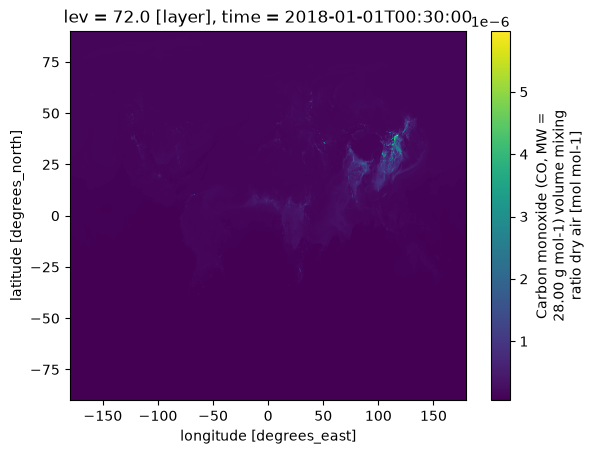

In [7]:
CO.plot()

/Users/danisanchez/miniconda3/envs/geol415/lib/python3.12/site-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


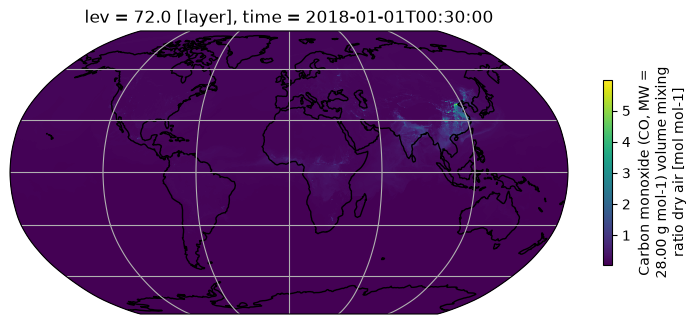

In [8]:
#Elementwise vs matrix operations
CO = ds.CO * 1e6 # convert to ppm

#Plotting basics
#coordinate reference system (map projection)
fig = plt.figure(figsize=(9,6))
ax = plt.axes(projection=ccrs.Robinson())
CO.plot(ax=ax, transform=ccrs.PlateCarree(), 
        cbar_kwargs={'shrink': 0.4}) # This line just makes the axis smaller
ax.coastlines()
ax.gridlines()

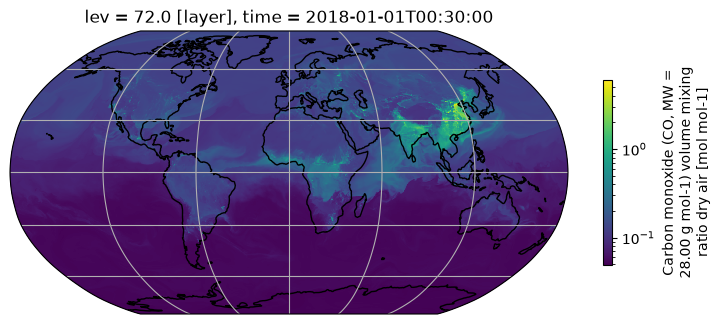

In [10]:
CO = ds.CO*1e6 

fig = plt.figure(figsize=(9,6))
ax = plt.axes(projection=ccrs.Robinson())
CO.plot(ax=ax, transform=ccrs.PlateCarree(),
        norm=colors.LogNorm(), # Normalize the colorbar in log scale
        cbar_kwargs={'shrink': 0.4},)
ax.coastlines()
ax.gridlines()

In [11]:
CO.sel(lat=[32.2540], lon=[-110.9742], method="nearest")


<xarray.DataArray 'CO' (time: 1, lev: 1, lat: 1, lon: 1)> Size: 4B
array([[[[0.17340425]]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8B 2018-01-01T00:30:00
  * lev      (lev) float64 8B 72.0
  * lat      (lat) float64 8B 32.25
  * lon      (lon) float64 8B -111.0
Attributes:
    long_name:       Carbon monoxide (CO, MW = 28.00 g mol-1) volume mixing r...
    units:           mol mol-1
    fmissing_value:  1e+15
    standard_name:   Carbon monoxide (CO, MW = 28.00 g mol-1) volume mixing r...
    vmin:            -1e+15
    vmax:            1e+15
    valid_range:     [-1.e+15  1.e+15]

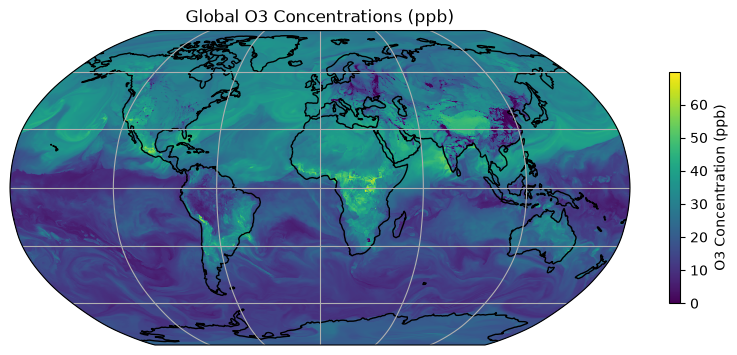

In [12]:
# 1. Extract and convert O3 to parts per billion (ppb)
O3 = ds.O3 * 1e9  # Adjust identifier to lowercase 'o3' if ds.O3 raises an error

# 2. Plotting basics with Map Projection
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.Robinson())

# 3. Generate the spatial map
O3.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'shrink': 0.5, 'label': 'O3 Concentration (ppb)'}
)

# 4. Add map boundaries and reference lines
ax.coastlines()
ax.gridlines()

plt.title("Global O3 Concentrations (ppb)")
plt.show()


In [13]:
max_idx = O3.argmax(dim=['lat', 'lon'])
min_idx = O3.argmin(dim=['lat', 'lon'])

In [20]:
max_lat = O3.lat[max_idx['lat']].values
max_lon = O3.lon[max_idx['lon']].values
max_val = O3.max().values

min_lat = O3.lat[min_idx['lat']].values
min_lon = O3.lon[min_idx['lon']].values
min_val = O3.min().values

print(f"Highest O3 is {max_val:.2f} ppb at Latitude: {max_lat}, Longitude: {max_lon}")
print(f"Lowest O3 is {min_val:.2f} ppb at Latitude: {min_lat}, Longitude: {min_lon}") 

Highest O3 is 69.73 ppb at Latitude: [[34.5]], Longitude: [[-118.75]]
Lowest O3 is 0.00 ppb at Latitude: [[53.]], Longitude: [[73.25]]


In [19]:
# --- e & f: Querying Los Angeles and Hawaii ---
# Los Angeles coordinates (approx: 34.0522° N, 118.2437° W)
O3_LA = O3.sel(lat=34.0522, lon=-118.2437, method='nearest').values.item()
print(f"O3 concentration over Los Angeles: {O3_LA:.2f} ppb")

# Hawaii/Honolulu coordinates (approx: 21.3069° N, 157.8583° W)
O3_Hawaii = O3.sel(lat=21.3069, lon=-157.8583, method='nearest').values.item()
print(f"O3 concentration over Hawaii: {O3_Hawaii:.2f} ppb")


O3 concentration over Los Angeles: 45.40 ppb
O3 concentration over Hawaii: 35.51 ppb
